In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as plt
from obspy import read, Stream

# Path dataset raw (ubah sesuai lokasimu)
input_root = r"E:\Skripsi\DEC\0-data2025\filtered_events"
output_root = r"E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru"
input_length=3000

all_folder = os.path.join(input_root, "all lama")


os.makedirs(output_root, exist_ok=True)


In [2]:
def count_short_samples(all_folder, min_length=3000):
    """
    Hitung berapa banyak waveform dengan panjang < min_length.
    """
    short_count = 0
    total_count = 0
    lengths = []

    for filename in sorted(os.listdir(all_folder)):
        if filename.endswith(".mseed"):
            file_path = os.path.join(all_folder, filename)
            st = read(file_path)

            for tr in st:
                    total_count += 1
                    lengths.append(tr.stats.npts)
                    if tr.stats.npts < min_length:
                        short_count += 1

    print(f"Total traces ditemukan : {total_count}")
    print(f"Traces < {min_length}  : {short_count}")
    print(f"Traces >= {min_length} : {total_count - short_count}")
    return lengths

lengths = count_short_samples(all_folder,  min_length=3000)


Total traces ditemukan : 2837
Traces < 3000  : 393
Traces >= 3000 : 2444


In [3]:

records = []
input_length = 3000  # keep this consistent with your model input
padding_counter = {"padded": 0}

def map_label(label):
    return label

def clean_trace(tr, input_length=3000):
    tr.detrend("linear")
    tr.filter("bandpass", freqmin=1, freqmax=15, zerophase=True,)
    data = tr.data.astype(np.float32)

    # Normalisasi lokal (per trace)
    mean = np.mean(data)
    std = np.std(data)
    data = (data - mean) / (std + 1e-8)

    # Padding / trimming
    if len(data) < input_length:
        ref = data[:200]
        mu, sigma = np.mean(ref), np.std(ref)
        pad_length = input_length - len(data)
        gaussian_pad = np.random.normal(mu, sigma, pad_length).astype(np.float32)
        data = np.concatenate([data, gaussian_pad])
        padding_counter["padded"] += 1
    else:
        data = data[:input_length]


    return data

for filename in sorted(os.listdir(all_folder)):
    if not filename.endswith(".mseed"):
        continue

    file_path = os.path.join(all_folder, filename)
    base = os.path.splitext(filename)[0]
    label = base.split("-")[-1].upper()
    if label not in ["MP", "ROCKFALL", "VTB"]:
        continue

    label_folder = os.path.join(output_root, label)
    os.makedirs(label_folder, exist_ok=True)

    st = read(file_path)
    for tr in st:
        # Bersihkan dan normalisasi lokal
        data = clean_trace(tr, input_length)

        # Simpan hasil
        out_file = base + ".mseed"
        out_path = os.path.join(label_folder, out_file)
        new_tr = tr.copy()
        new_tr.data = data
        Stream(traces=[new_tr]).write(out_path, format="MSEED")

        records.append({
            "path": out_path,
            "label": label,
            "filename": out_file,
            "station": tr.stats.station,
            "channel": tr.stats.channel,
            "sampling_rate": tr.stats.sampling_rate  # keep original sampling
        })

manifest = pd.DataFrame(records)
manifest_path = os.path.join(output_root, "manifest.csv")
manifest.to_csv(manifest_path, index=False)

print(f"Cleaning dan normalisasi lokal selesai  Total file: {len(manifest)}")
print(f"Total file yang dipadding: {padding_counter['padded']}")


e:\Skripsi\DEC\envTA\lib\site-packages\obspy\io\mseed\core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


Cleaning dan normalisasi lokal selesai  Total file: 2808
Total file yang dipadding: 389


In [4]:
print("Distribusi tiap folder : ") 
print(manifest["label"].value_counts())
print(f"Manifest tersimpan di: {manifest_path}")


Distribusi tiap folder : 
label
MP          1430
ROCKFALL    1252
VTB          126
Name: count, dtype: int64
Manifest tersimpan di: E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\manifest.csv


Label: MP
E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_00-26-05-MP.mseed


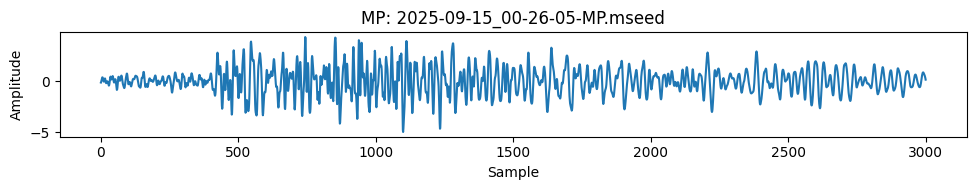

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_00-40-59-MP.mseed


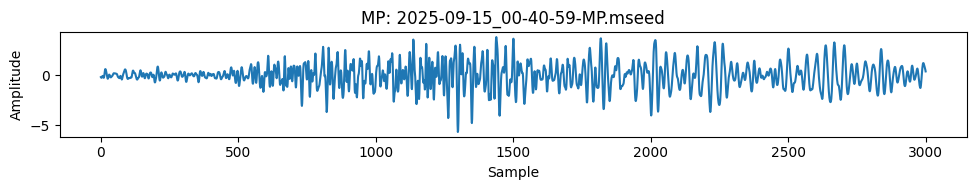

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_00-56-07-MP.mseed


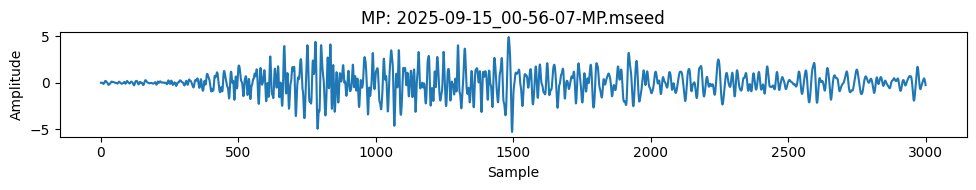

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_01-00-18-MP.mseed


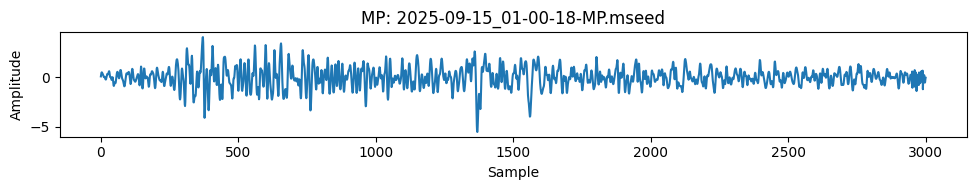

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_01-31-25-MP.mseed


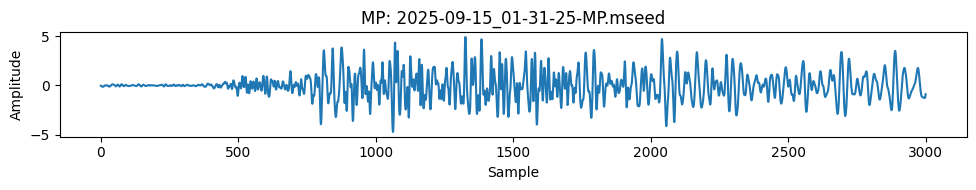

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_01-39-27-MP.mseed


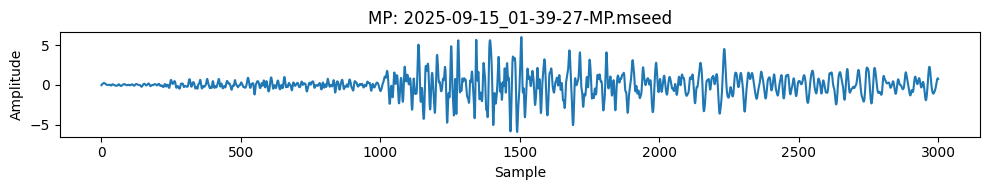

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_02-11-25-MP.mseed


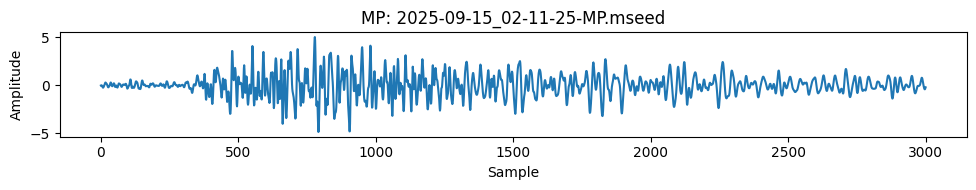

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_02-51-09-MP.mseed


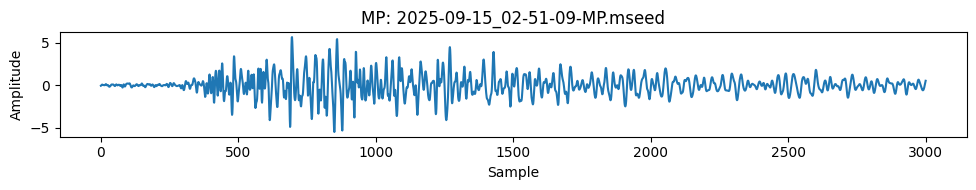

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_03-11-20-MP.mseed


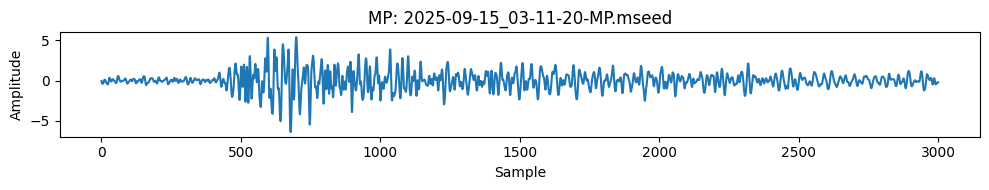

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\MP\2025-09-15_03-14-04-MP.mseed


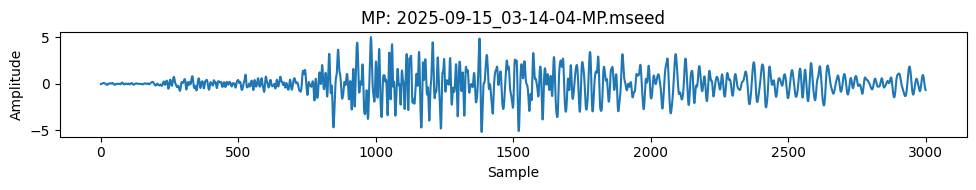

----------------------------------------
Label: ROCKFALL
E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_00-14-34-ROCKFALL.mseed


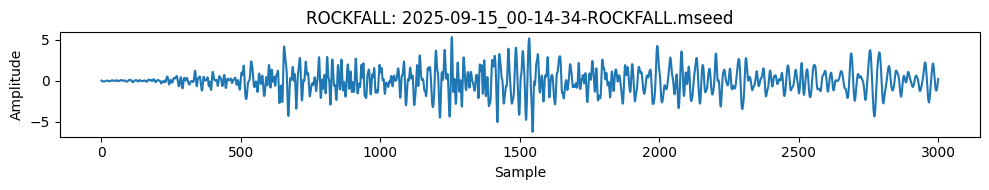

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_00-39-56-ROCKFALL.mseed


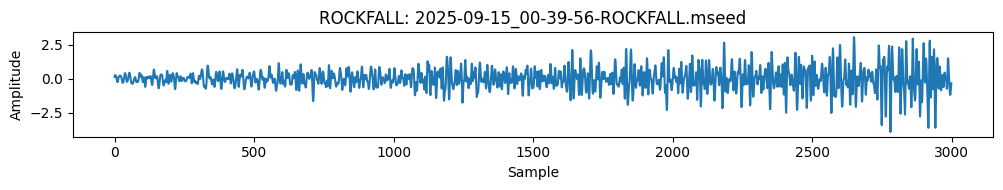

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_01-02-48-ROCKFALL.mseed


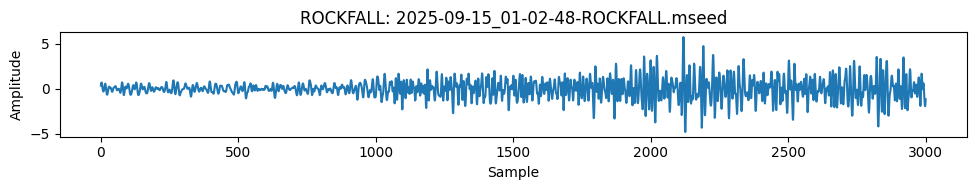

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_01-41-31-ROCKFALL.mseed


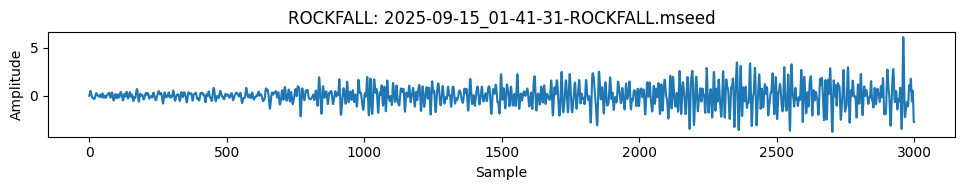

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_01-50-49-ROCKFALL.mseed


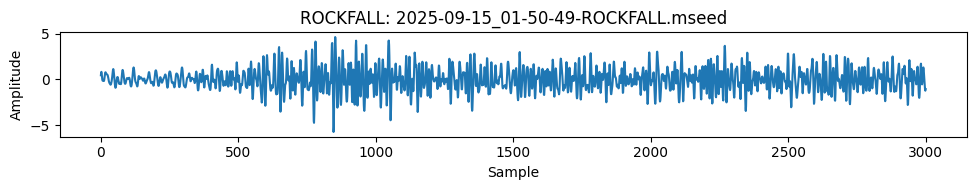

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_01-59-53-ROCKFALL.mseed


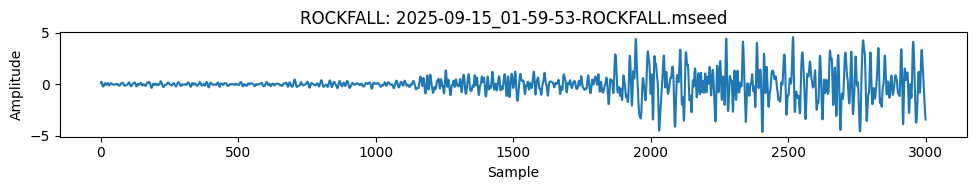

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_02-16-16-ROCKFALL.mseed


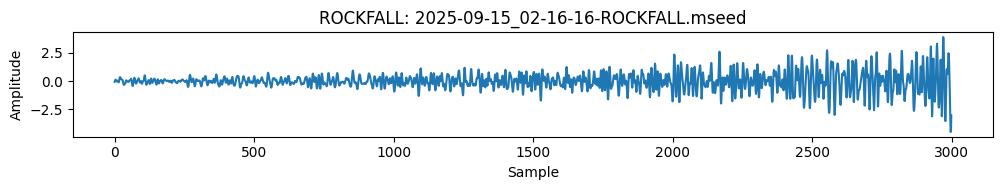

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_02-39-52-ROCKFALL.mseed


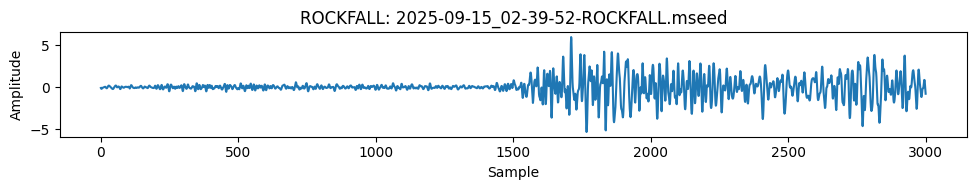

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_02-45-12-ROCKFALL.mseed


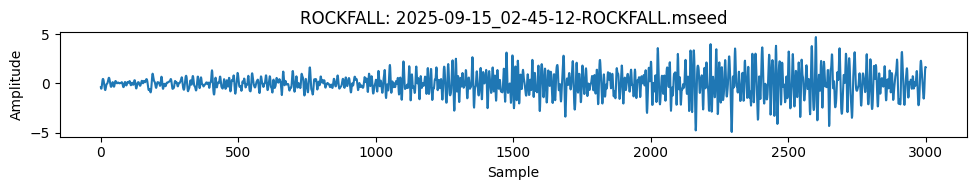

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\ROCKFALL\2025-09-15_03-03-13-ROCKFALL.mseed


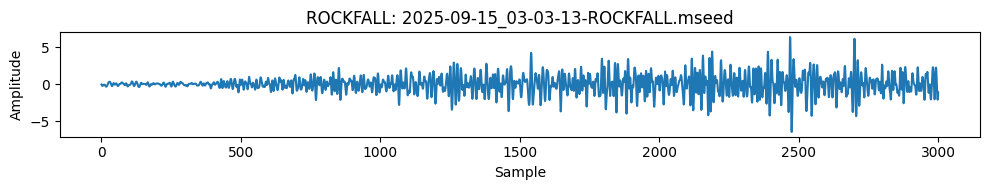

----------------------------------------
Label: VTB
E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-15_01-08-51-VTB.mseed


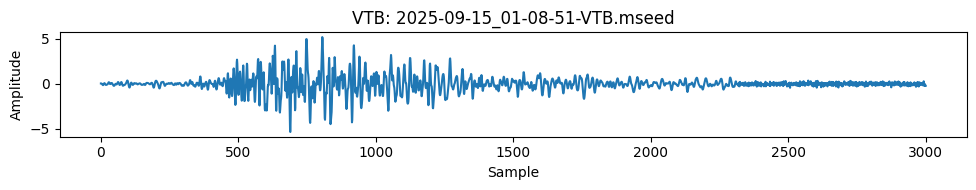

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-15_05-42-39-VTB.mseed


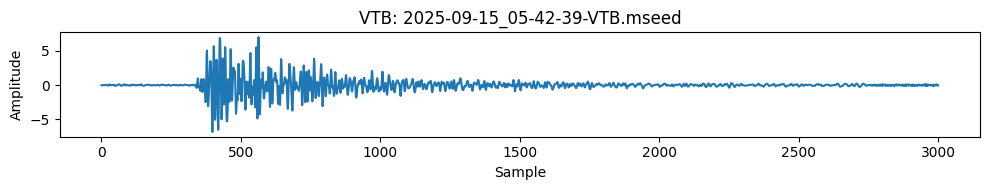

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-15_07-49-41-VTB.mseed


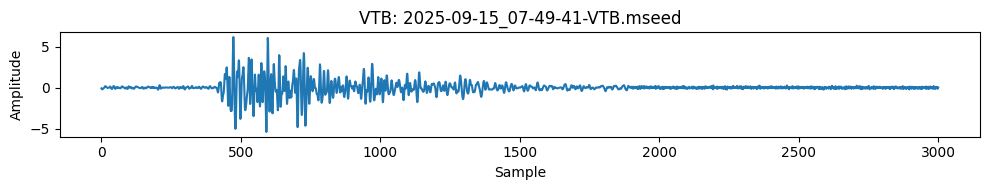

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-15_07-52-54-VTB.mseed


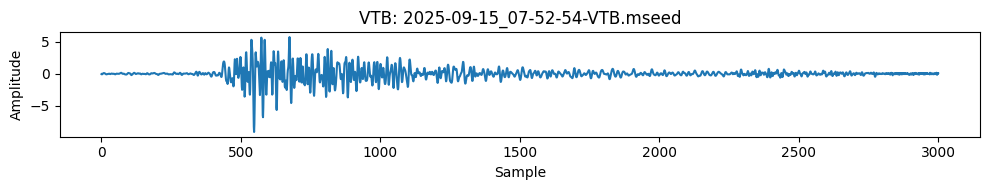

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-16_09-03-10-VTB.mseed


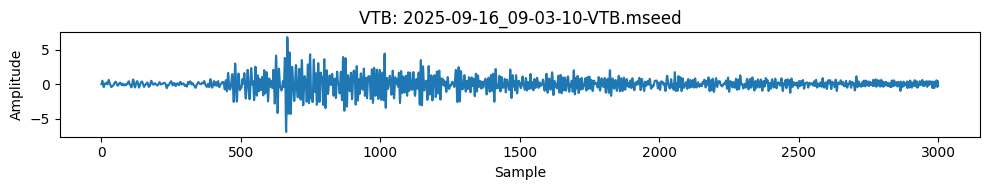

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-17_01-28-53-VTB.mseed


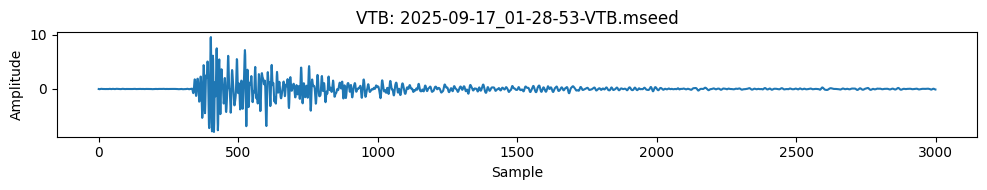

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-17_03-31-49-VTB.mseed


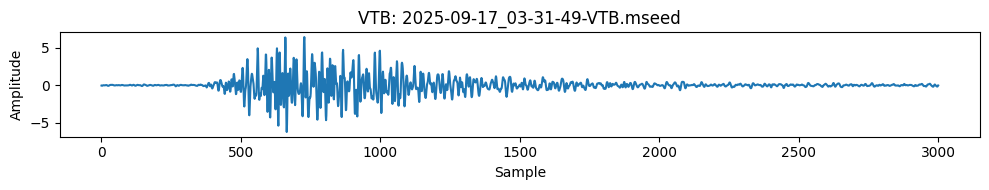

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-17_06-59-49-VTB.mseed


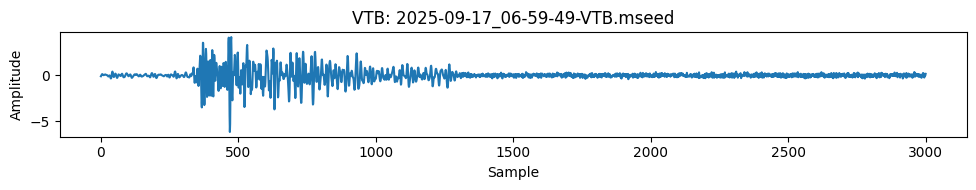

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-17_19-43-08-VTB.mseed


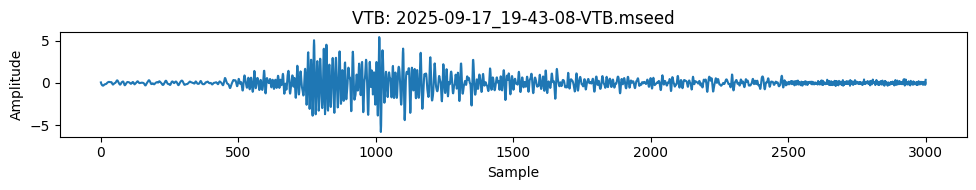

E:\Skripsi\DEC\dataset\ae-supervised-dataset\cleaned-baru\VTB\2025-09-18_06-51-01-VTB.mseed


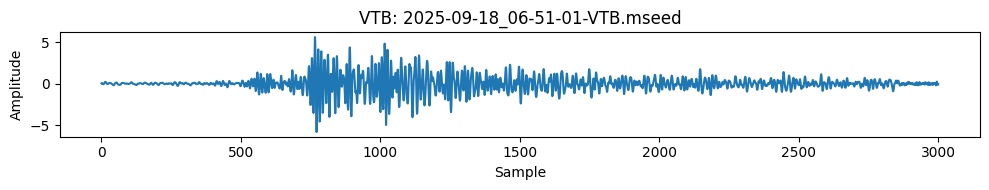

----------------------------------------


In [5]:
import matplotlib.pyplot as plt

files_per_label = manifest.groupby('label').head(10)
for label, group in files_per_label.groupby('label'):
    print(f"Label: {label}")
    for path in group['path']:
        print(path)
        # Plot waveform
        st = read(path)
        tr = st[0]
        plt.figure(figsize=(10, 2))
        plt.plot(tr.data)
        plt.title(f"{label}: {os.path.basename(path)}")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()
    print("-" * 40)
